

### Завдання 1: Виклик LLM з базовим промптом

**Мета:** навчитися викликати LLM через LangChain зі звичайним текстовим промптом.

**Що потрібно зробити:**

1. Створіть промпт, який дозволяє отримати інформацію простою мовою на тему "Квантові обчислення". Відповідь моделі повинна містити визначення, ключові переваги та поточні дослідження в цій галузі.

2. Обмежте відповідь до 200 символів і пропишіть в промпті, аби відповідь була короткою (це зекономить вам час і гроші на згенеровані токени).

3. Встановіть своє значення температури на власний розсуд (тут немає правильного чи неправильного значення) і напишіть коментарем, чому ви обрали саме таке значення для цього завдання.

**Вибір моделі:** можна скористатись як моделлю з HuggingFace, так і ChatGPT будь-якої версії, яка вам до вподоби і пасує за прайсингом. В обох випадках потрібно імпортувати відповідний клас з LangChain для виклику LLM за API.

**Мова запитів:** промпти можна писати як українською, так і англійською — орієнтуйтесь на те, де і для чого ви хочете потім використовувати цей проєкт. У розв'язках промпти — українською.

---

**🔐 Як безпечно зберігати і підвантажувати API-ключі**

API-токен потрібно зчитувати з безпечного джерела, а **не хардкодити в ноутбуці**. Якщо хтось отримає доступ до вашого ключа, він буде витрачати токени за ваш рахунок, а вам це не треба :)

Є кілька способів. Перший ми використовували на лекції, ще два для розширення вашого розуміння, як ще це можна зробити і що шлях не лише один. Для виконання цього ДЗ можете використовувати будь-який спосіб підвантаження ключів у ноутбук.

**Спосіб 1: Файл `creds.json` (рекомендований)**

Створіть файл `creds.json` з вашими ключами, завантажте його в Google Colab під час роботи, але **не здавайте** цей файл у ДЗ і **не комітьте** в git.

```python
import json
with open("creds.json") as f:
    creds = json.load(f)
api_key = creds["HF_TOKEN"]
```

**Спосіб 2: Google Colab Secrets**

У лівій панелі Colab натисніть іконку 🔑 (Secrets) → "Add new secret" → введіть назву (наприклад, `HF_TOKEN`) та значення ключа → увімкніть тогл доступу для ноутбука.

```python
from google.colab import userdata
api_key = userdata.get("HF_TOKEN")
```

Зручно тим, що ключ зберігається в акаунті і доступний у всіх ваших ноутбуках. Мінус — при кожній новій сесії потрібно перевірити, що доступ увімкнено.

**Спосіб 3: Google AI Studio (для Gemini API)**

Якщо працюєте з моделями Google Gemini, отримати безкоштовний API-ключ можна в [Google AI Studio](https://aistudio.google.com/app/apikey): увійдіть з Google-акаунтом → натисніть "Get API key" → "Create API key". Далі використовуйте ключ через будь-який із способів вище.



In [10]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import Runnable

# All api keys are in os.environ
import os

# use 0.1 to make responses quite conservative and less random
overall_temperature = 0.1

# create open ai chat model
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=overall_temperature,
    max_tokens=600, # limit output tokens
)

# define helper function
def query_llm(
    llm: Runnable[str, AIMessage],
    question: str,
    verbose: bool = True,
) -> AIMessage:
    """
    Send a prompt to a LangChain chat model and return the AIMessage response.

    Args:
        llm: Any LangChain chat model implementing `.invoke()` that returns `AIMessage`.
        question (str): The user prompt to send to the model.
        verbose (bool, optional): If True, prints the response content. Defaults to True.

    Returns:
        AIMessage:
            The complete response from the model.
    """
    response = llm.invoke(question)

    if verbose:
        print(response.content)

    return response


In [13]:
query_llm(llm, "Explain very shortly (under 500 characters if possible) and not too complicated what Quantum computing is. Include into response main definitions, key benefits, and current research in the field.");

Quantum computing is a type of computing that uses quantum bits (qubits) instead of classical bits. Qubits can exist in multiple states simultaneously, allowing quantum computers to process vast amounts of data more efficiently. Key benefits include solving complex problems faster, such as optimization, cryptography, and drug discovery. Current research focuses on improving qubit stability, error correction, and developing practical applications across various industries, including finance, healthcare, and materials science.


### Завдання 2: Створення параметризованого промпта для генерації тексту
Тепер ми хочемо оновити попередній фукнціонал так, аби в промпт ми могли передавати тему як параметр. Для цього скористайтесь `PromptTemplate` з `langchain` і реалізуйте параметризований промпт та виклик моделі з ним.

Запустіть оновлений функціонал (промпт + модел) для пояснень про теми
- "Баєсівські методи в машинному навчанні"
- "Трансформери в машинному навчанні"
- "Explainable AI"

Виведіть результати відпрацювання моделі на екран.

In [14]:
prompt = PromptTemplate(
    input_variables=["topic"],
    template="Explain very shortly (under 500 characters if possible) and not too complicated what {topic} is. Include into response main definitions, key benefits, and current research in the field.",
)

print(prompt.format(topic="donuts"))

Explain very shortly (under 500 characters if possible) and not too complicated what donuts is. Include into response main definitions, key benefits, and current research in the field.


In [16]:
query_llm(llm, prompt.format(topic="Bayesian methods in machine learning"));

Bayesian methods in machine learning use Bayes' theorem to update the probability of a hypothesis as more evidence becomes available. Key definitions include prior (initial belief), likelihood (evidence), and posterior (updated belief). Benefits include handling uncertainty, incorporating prior knowledge, and providing probabilistic interpretations of predictions. Current research focuses on improving computational efficiency, developing scalable algorithms, and applying Bayesian methods to deep learning, reinforcement learning, and causal inference.


In [17]:
query_llm(llm, prompt.format(topic="Transformers in machine learning"));

Transformers are a type of neural network architecture designed for processing sequential data, primarily used in natural language processing (NLP). They rely on self-attention mechanisms to weigh the importance of different words in a sentence, allowing for better context understanding. Key benefits include parallel processing, improved performance on long-range dependencies, and scalability. Current research focuses on enhancing efficiency, reducing model size, and applying Transformers to various domains like computer vision and audio processing.


In [18]:
# use chain this time
chain = prompt | llm | StrOutputParser()

result = chain.invoke({"topic": "Explainable AI"})
print(result)

Explainable AI (XAI) refers to methods and techniques that make the outputs of AI systems understandable to humans. Key definitions include interpretability (how well a human can understand the model's decisions) and transparency (how clear the model's processes are). Benefits include increased trust, accountability, and compliance with regulations. Current research focuses on developing algorithms that provide insights into model behavior, creating visualizations for better understanding, and ensuring fairness and bias mitigation in AI systems.




### Завдання 3: Використання агента для автоматизації процесів
Створіть агента, який допоможе автоматично шукати інформацію про останні наукові публікації в різних галузях. Наприклад, агент має знайти 5 останніх публікацій на тему штучного інтелекту.

**Кроки:**
1. Налаштуйте агента типу ReAct в LangChain для виконання автоматичних запитів.
2. Створіть промпт, який спрямовує агента шукати інформацію в інтернеті або в базах даних наукових публікацій.
3. Агент повинен видати список публікацій, кожна з яких містить назву, авторів і короткий опис.

Для взаємодії з пошуком там необхідно створити `Tool`. В лекції ми використовували `serpapi`. Можна продовжити користуватись ним, або обрати інше АРІ для пошуку (вони в тому числі є безкоштовні). Перелік різних АРІ, доступних в langchain, і орієнтир по вартості запитів можна знайти в окремому документі [тут](https://hannapylieva.notion.site/API-12994835849480a69b2adf2b8441cbb3?pvs=4).

Лишаю також нижче приклад використання одного з безкоштовних пошукових АРІ - DuckDuckGo (не потребує створення токена!)  - можливо він вам сподобається :)


In [ ]:
# !pip install -q langchain_community duckduckgo_search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 35.8 MB/s eta 0:00:00


In [ ]:
# from langchain_community.tools import DuckDuckGoSearchRun

# search = DuckDuckGoSearchRun()

# search.invoke("Obama's first name?")

"2 of 2. Barack Obama: timeline Key events in the life of Barack Obama. Barack Obama (born August 4, 1961, Honolulu, Hawaii, U.S.) is the 44th president of the United States (2009-17) and the first African American to hold the office. Before winning the presidency, Obama represented Illinois in the U.S. Senate (2005-08). Since the office was established in 1789, 45 men have served in 46 presidencies. The first president, George Washington, won a unanimous vote of the Electoral College. [4] Grover Cleveland served two non-consecutive terms and is therefore counted as the 22nd and 24th president of the United States, giving rise to the discrepancy between the ... Here is a list of the presidents and vice presidents of the United States along with their parties and dates in office. ... Chester A Arthur: Twenty-First President of the United States. 10 Interesting Facts About James Buchanan. Martin Van Buren - Eighth President of the United States. Quotes From Harry S. Truman. Table of Cont

In [44]:
from typing import List
from langchain.tools import tool
from serpapi import GoogleSearch


# create a tool that directly call SerpAPI’s Google Scholar API
# SerpAPI docs for Google Scholar engine:
# https://serpapi.com/google-scholar-api
# Google scholar search
# https://scholar.google.com/
@tool
def scholar_search(query: str) -> List[dict]:
    """
    Search Google Scholar for recent scientific publications.

    Returns a list of publications with:
    - title
    - authors
    - snippet (short description)
    """
    params = {
        "engine": "google_scholar",                 # Other engines: "google", "google_news", "bing", etc.
        "q": query,                                 # search query string 
        "hl": "en",                                 # ensures English titles/snippets
        "num": 5,                                   # number of results - exactly 5 publications
        "sort": "date",                             # Sort results by newest publications - add latest publications to results
        "api_key": os.getenv("SERPAPI_API_KEY"),    # authenticates the request
    }

    search = GoogleSearch(params)
    results = search.get_dict()

    publications = []
    for item in results.get("organic_results", []):
        title = item.get("title")
        authors = item.get("publication_info", {}).get("summary")
        snippet = item.get("snippet")

        publications.append(
            f"Title: {title}\nAuthors: {authors}\nDescription: {snippet}\n"
        )

    return "\n".join(publications)

In [45]:
# ChatPromptTemplate approach worked well for this version. Was not able to achive the same with PromptTemplate
react_chat_prompt = ChatPromptTemplate.from_messages([
    ("system", """
You are a research assistant.

Your task is to find the 5 most recent scientific publications about the topic provided by the user.

For each publication, extract:
- Title
- Authors
- Short description

Return the final answer as a clear formatted list.
"""),
    ("placeholder", "{messages}"),
])

In [46]:
!pip show langchain

Name: langchain
Version: 1.2.13
Summary: Building applications with LLMs through composability
Home-page: https://docs.langchain.com/
Author: 
Author-email: 
License: MIT
Location: /opt/miniconda3/envs/mlpeople5/lib/python3.11/site-packages
Requires: langchain-core, langgraph, pydantic
Required-by: 


In [47]:
# a bit mess with versions:
# create_react_agent will be depracated in V2 (or maybe not)
# create_react_agent existed in langgraph.agents at some point and supported prompt parameter (maybe in v0.1 ? or maybe not)
# create_react_agent now in langgraph.prebuilt (Version: 1.2.13)
# should 'from langchain.agents import create_agent' be used here (or maybe not?). it does not support prompt param? but has system_prompt? who knows ? probably all will be changed until we realize
# next version - next rules - ai takes over the world
from langgraph.prebuilt import create_react_agent

llm = ChatOpenAI(model="gpt-4o-mini", temperature=overall_temperature)

agent = create_react_agent(
    model=llm,
    tools=[scholar_search],
    prompt=react_chat_prompt,
)

/var/folders/0s/q_d47bvj0hq4rs_6q_06d63m0000gn/T/ipykernel_9459/1361646062.py:11: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


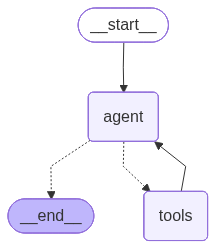

In [48]:
agent

In [49]:
result = agent.invoke(
    {
        "messages": [
            ("user", "Artificial Intelligence")
        ]
    }
)

# print only last message
print(result["messages"][-1].content)

Here are the 5 most recent scientific publications on the topic of Artificial Intelligence:

1. **Title:** Education in the era of generative artificial intelligence (AI): Understanding the potential benefits of ChatGPT in promoting teaching and learning  
   **Authors:** D Baidoo-Anu, LO Ansah  
   **Description:** This paper explores the potential benefits of ChatGPT in education, highlighting its capabilities in performing complex tasks, including writing and debugging original computer code.

2. **Title:** Scientific discovery in the age of artificial intelligence  
   **Authors:** H Wang, T Fu, Y Du, W Gao, K Huang, Z Liu  
   **Description:** This publication discusses the integration of artificial intelligence in scientific discovery, emphasizing how AI can augment and accelerate research by helping scientists generate hypotheses and design experiments.

3. **Title:** A review of the role of artificial intelligence in healthcare  
   **Authors:** A Al Kuwaiti, K Nazer, A Al-Reed

In [56]:
# check all process in human readable format function
def print_agent_result(result):
    print("\n=== START ===\n")

    for msg in result["messages"]:

        if isinstance(msg, HumanMessage):
            print(f"[USER]\n{msg.content}\n")

        elif isinstance(msg, AIMessage):
            # Tool call request (ReAct thinking step)
            if msg.tool_calls:
                for call in msg.tool_calls:
                    print(f"[TOOL CALL] {call['name']}({call['args']})\n")

            # Final LLM response
            elif msg.content.strip():
                print(f"[LLM]\n{msg.content}\n")

        elif isinstance(msg, ToolMessage):
            print(f"[TOOL RESULT] ({msg.name})\n{msg.content}\n")

    print("=== END ===\n")

In [55]:
print_agent_result(result)


=== START ===

[USER]
Artificial Intelligence

[TOOL CALL] scholar_search({'query': 'Artificial Intelligence'})

[TOOL RESULT] (scholar_search)
Title: Artificial intelligence
Authors: EB Hunt - 2014 - books.google.com
Description: Artificial Intelligence provides information pertinent to the fundamental aspects of artificial intelligence. This book presents the basic mathematical and computational approaches to …

Title: Artificial intelligence in medicine
Authors: J Holmes, L Sacchi, R Bellazzi - Ann R Coll Surg Engl, 2004 - Springer
Description: The European Society for Artificial Intelligence in Medicine (AIME) was established in 1986 following a very successful workshop held in Pavia, Italy, the year before. The principal aims …

Title: Quo vadis artificial intelligence?
Authors: Y Jiang, X Li, H Luo, S Yin, O Kaynak - Discover Artificial Intelligence, 2022 - Springer
Description: … intelligence into machines, which constitutes the original motivation of Artificial Intelligence (A

<span style="background-color: #f60;display:block">

 - Interesting from above that for first query result from google search returned some old articles from years 2017 and up to 1990. After that LLM decided to call a tool with refined search query specifing the last year its aware of - 'query': 'Artificial Intelligence 2023'
 
</span>

In [61]:
# use create_agent approach here
from langchain.agents import create_agent

agent_v2 = create_agent(
    model=llm,
    tools=[scholar_search],
    system_prompt="You are a helpful assistant that can use scholar web search tool to look for different kind of scientific publications."
)

def query_agent_v2(query):
    return agent_v2.invoke(
    {
        "messages": [{
            "role": "user",
            "content": query
        }]
    }
)

In [62]:
result2 = query_agent_v2("Find the 5 most recent scientific publications about Artificial Intelligence. For each publication, extract: title, authors and short description")

In [63]:
print_agent_result(result2)


=== START ===

[USER]
Find the 5 most recent scientific publications about Artificial Intelligence. For each publication, extract: title, authors and short description

[TOOL CALL] scholar_search({'query': 'Artificial Intelligence'})

[TOOL RESULT] (scholar_search)
Title: Artificial intelligence
Authors: EB Hunt - 2014 - books.google.com
Description: Artificial Intelligence provides information pertinent to the fundamental aspects of artificial intelligence. This book presents the basic mathematical and computational approaches to …

Title: Artificial intelligence in medicine
Authors: J Holmes, L Sacchi, R Bellazzi - Ann R Coll Surg Engl, 2004 - Springer
Description: The European Society for Artificial Intelligence in Medicine (AIME) was established in 1986 following a very successful workshop held in Pavia, Italy, the year before. The principal aims …

Title: Quo vadis artificial intelligence?
Authors: Y Jiang, X Li, H Luo, S Yin, O Kaynak - Discover Artificial Intelligence, 2022 - S

<span style="background-color: #f60;display:block">

 - Different approach but exactly the same result as before with `create_react_agent` approach
 
</span>



### Завдання 4: Створення агента-помічника для вирішення бізнес-задач

Створіть агента, який допомагає вирішувати задачі бізнес-аналітики. Агент має допомогти користувачу створити прогноз по продажам на наступний рік враховуючи рівень інфляції і погодні умови. Агент має вміти використовувати Python і ходити в інтернет аби отримати актуальні дані.

**Кроки:**
1. Налаштуйте агента, який працюватиме з аналітичними даними, заданими текстом. Користувач пише

```
Ми експортуємо апельсини з Бразилії. В 2022 експортували 200т, в 2023 - 190т, в 2024 - 210т, в 2025 - 220т. Зроби оцінку скільки ми зможемо експортувати апельсинів в 2026 враховуючи погодні умови в Бразилії і попит на апельсини в світі виходячи з економічної ситуації.
```

2. Створіть запит до агента, що містить чітке завдання – видати результат бізнес аналізу або написати, що він не може цього зробити і запит користувача (просто може бути все одним повідомлленням).

3. Запустіть агента і проаналізуйте результати. Що можна покращити?


In [64]:
# create few other tools for web-search
def web_search(query: str) -> str:
    """Search the web using Google via SerpAPI.."""
    params = {
        "q": query,
        "api_key": os.getenv("SERPAPI_API_KEY"),
        "engine": "google",
        "num": 3,
    }
    search = GoogleSearch(params)
    results = search.get_dict()
    snippets = [r.get("snippet", "") for r in results.get("organic_results", [])[:3]]
    return "\n".join(snippets)

@tool
def bing_search(query: str) -> str:
    """Search the web using Bing via SerpAPI."""
    params = {
        "engine": "bing",               # Bing engine
        "q": query,                     # Search query
        "api_key": os.getenv("SERPAPI_API_KEY"),
        "num": 3,                       # Top 3 results
        "hl": "en"                      # Language
    }

    search = GoogleSearch(params)
    results = search.get_dict()
    snippets = [r.get("snippet", "") for r in results.get("organic_results", [])[:3]]
    return "\n".join(snippets)

@tool
def google_news_search(query: str) -> str:
    """Search Google News for recent articles via SerpAPI."""
    params = {
        "engine": "google_news",        # Google News engine
        "q": query,
        "api_key": os.getenv("SERPAPI_API_KEY"),
        "num": 5,                        # Top 5 articles
        "hl": "en"
    }

    search = GoogleSearch(params)
    results = search.get_dict()
    snippets = []

    # Google News returns a list of news articles
    for article in results.get("news_results", [])[:5]:
        title = article.get("title", "")
        source = article.get("source", "")
        snippet = article.get("snippet", "")
        snippets.append(f"{title} ({source}): {snippet}")

    return "\n".join(snippets)

@tool
def calculator(expression: str) -> str:
    """Evaluate a simple math expression."""
    try:
        return str(eval(expression))
    except Exception as e:
        return f"Error: {e}"
    

@tool
def python_interpreter(code: str) -> str:
    """Execute Python code using print() to return results."""
    local_vars = {}
    try:
        exec(code, {}, local_vars)
        return str(local_vars)
    except Exception as e:
        return f"Error: {e}"

In [66]:
# use create_agent approach here
from langchain.agents import create_agent

agent_v3 = create_agent(
    model=llm,
    tools=[scholar_search, web_search, bing_search, google_news_search, calculator, python_interpreter],
    system_prompt="You are a helpful assistant that can use tools for math, python code, and differnt types of web search to helps solve business analytics problems."
)

# helper function to print stream result
def print_agent_stream(agent, user_question):
    print("\n=== STREAMING AGENT TRACE ===\n")

    for chunk in agent.stream(
        {"messages": [{"role": "user", "content": user_question}]}
    ):
        # Each chunk is: {'model': {...}} OR {'tools': {...}}
        for node_name, node_data in chunk.items():
            messages = node_data.get("messages", [])

            for msg in messages:
                # USER (rarely appears in stream)
                if isinstance(msg, HumanMessage):
                    print(f"[USER]\n{msg.content}\n")

                # LLM output or tool calls
                elif isinstance(msg, AIMessage):
                    if msg.tool_calls:
                        for call in msg.tool_calls:
                            print(f"[TOOL CALL] {call['name']}({call['args']})\n")
                    elif msg.content.strip():
                        print(f"[LLM]\n{msg.content}\n")

                # Tool result
                elif isinstance(msg, ToolMessage):
                    print(f"[TOOL RESULT] ({msg.name})\n{msg.content}\n")

    print("=== END STREAM ===\n")

In [71]:
print_agent_stream(agent_v3, "We export oranges from Brazil. In 2022 we exported 200t, in 2023 - 190t, in 2024 - 210t, in 2025 - 220t. Estimate how many oranges we will be able to export in 2026, taking into account weather conditions in Brazil and the demand for oranges in the world based on the economic situation.")


=== STREAMING AGENT TRACE ===

[TOOL CALL] calculator({'expression': '220 + 6.67'})

[TOOL RESULT] (calculator)
226.67

[LLM]
Based on the average annual change, the estimated exports for 2026 would be approximately **226.67 tons**.

### Considerations
While this estimate is based on historical data, it's important to consider external factors such as:

1. **Weather Conditions**: Adverse weather can significantly impact orange production.
2. **Global Demand**: Economic conditions and consumer preferences can affect demand for oranges.
3. **Market Trends**: Changes in trade policies, tariffs, and competition from other countries can also influence export volumes.

If you have specific insights or data regarding these factors, they could further refine the estimate.

=== END STREAM ===



In [73]:
print_agent_stream(agent_v3, "We export oranges from Brazil. In 2022 we exported 200t, in 2023 - 190t, in 2024 - 210t, in 2025 - 220t. Estimate how many oranges we will be able to export in 2026, taking into account weather conditions in Brazil and the demand for oranges in the world based on the economic situation.")


=== STREAMING AGENT TRACE ===

[TOOL CALL] python_interpreter({'code': '# Given data\nexports = [200, 190, 210, 220]\n\n# Calculate year-over-year growth rates\ngrowth_rates = []\nfor i in range(1, len(exports)):\n    growth_rate = (exports[i] - exports[i-1]) / exports[i-1]\n    growth_rates.append(growth_rate)\n\n# Calculate average growth rate\naverage_growth_rate = sum(growth_rates) / len(growth_rates)\n\n# Forecast for 2026\nforecast_2026 = exports[-1] * (1 + average_growth_rate)\naverage_growth_rate, forecast_2026'})

[TOOL RESULT] (python_interpreter)
{'exports': [200, 190, 210, 220], 'growth_rates': [-0.05, 0.10526315789473684, 0.047619047619047616], 'i': 3, 'growth_rate': 0.047619047619047616, 'average_growth_rate': 0.034294068504594814, 'forecast_2026': 227.54469507101084}

[LLM]
The calculations yield the following results:

- **Average Growth Rate**: Approximately \(3.43\%\)
- **Estimated Exports for 2026**: Approximately \(227.54\) tons

### Conclusion
Based on the histori

In [72]:
print_agent_stream(agent_v3, "We export oranges from Brazil. In 2022 we exported 200t, in 2023 - 190t, in 2024 - 210t, in 2025 - 220t. Estimate how many oranges we will be able to export in 2026, taking into account current weather conditions in Brazil and the demand for oranges in the world based on the current economic situation.")


=== STREAMING AGENT TRACE ===

[TOOL CALL] web_search({'query': 'current weather conditions Brazil 2026 orange export'})

[TOOL CALL] web_search({'query': 'global demand for oranges 2026 economic situation'})

[TOOL RESULT] (web_search)
This annual report, published in January, includes data on U.S. and global trade, production, consumption and stocks, as well as analysis of ...
Global orange markets are heading into 2025-26 with renewed momentum, as growing orange juice consumption in the United States lifts worldwide ...
According to the World Citrus Organisation (WCO), the 2025–26 Northern Hemisphere orange production is forecast to decrease by 2.16% to 13.86 ...

[TOOL RESULT] (web_search)
From May 2025 to January 2026, the average accumulated rainfall was 10% lower than the historical average from 1991 to 2020. Only in the ...
According to Post contacts, weather conditions in 2025 were generally stable, which supported strong crop production. However, the citrus belt ...
It said 

<span style="background-color: #f60;display:block">

 - Agent's output is different from run to run even for the same query (temperature=0.1).

 - Just saying in prompt `taking into account weather conditions in Brazil and the demand for oranges in the world based on the economic situation.` does not motivate agent to search the information in web. Instead it uses math calcualtor, python executor and own analytical abilities to solve the problem

 - Only in case of using word `current` in prompt `taking into account CURRENT weather conditions in Brazil and the demand for oranges in the world based on the CURRENT economic situation.` agent starts by searching latest related news and weather conditions on web

</span>

In [74]:
prompt = """
We export oranges from Brazil. In 2022 we exported 200t, in 2023 - 190t, in 2024 - 210t, in 2025 - 220t.
Estimate how many oranges we will be able to export in 2026. 
Take into account current weather conditions in Brazil and the demand for oranges in the world based on the current economic situation.
Provide the result of the business analysis or write that you cannot do this if you are not sure or stuck for some reason
"""
print_agent_stream(agent_v3, prompt)


=== STREAMING AGENT TRACE ===

[TOOL CALL] google_news_search({'query': 'Brazil orange export weather conditions 2026'})

[TOOL CALL] google_news_search({'query': 'global demand for oranges 2026 economic situation'})

[TOOL RESULT] (google_news_search)
Fruit and Tree Nuts Outlook: March 2026 ({'name': 'FreshPlaza', 'icon': 'https://encrypted-tbn1.gstatic.com/faviconV2?url=https://www.freshplaza.com&client=NEWS_360&size=96&type=FAVICON&fallback_opts=TYPE,SIZE,URL'}): 
Brazil corn delays threaten global supply as dry season looms ({'name': 'Farm Progress', 'icon': 'https://encrypted-tbn1.gstatic.com/faviconV2?url=https://www.farmprogress.com&client=NEWS_360&size=96&type=FAVICON&fallback_opts=TYPE,SIZE,URL', 'authors': ['Brian Basting']}): 
World Orange and Orange Juice Projections ({'name': 'Citrus Industry Magazine', 'icon': 'https://encrypted-tbn3.gstatic.com/faviconV2?url=https://citrusindustry.net&client=NEWS_360&size=96&type=FAVICON&fallback_opts=TYPE,SIZE,URL'}): 
Global Concentra

<span style="background-color: #f60;display:block">

 - This time agent was able to provide meaningful and adequat conclusion based on latest news articles related to `Brazil orange export weather conditions 2026` and `global demand for oranges 2026 economic situation`

</span>